In [3]:
import pandas as pd
df2 = pd.read_excel("train.xlsx")
print(df2.shape)
print(df2.head())

(9800, 18)
   Row ID        Order ID           Order Date            Ship Date  \
0     1.0  CA-2017-152156  2017-08-11 00:00:00  2017-11-11 00:00:00   
1     2.0  CA-2017-152156  2017-08-11 00:00:00  2017-11-11 00:00:00   
2     3.0  CA-2017-138688  2017-12-06 00:00:00           16/06/2017   
3     4.0  US-2016-108966  2016-11-10 00:00:00           18/10/2016   
4     5.0  US-2016-108966  2016-11-10 00:00:00           18/10/2016   

        Ship Mode Customer ID    Customer Name    Segment        Country  \
0    Second Class    CG-12520      Claire Gute   Consumer  United States   
1    Second Class    CG-12520      Claire Gute   Consumer  United States   
2    Second Class    DV-13045  Darrin Van Huff  Corporate  United States   
3  Standard Class    SO-20335   Sean O'Donnell   Consumer  United States   
4  Standard Class    SO-20335   Sean O'Donnell   Consumer  United States   

              City       State  Postal Code Region       Product ID  \
0        Henderson    Kentucky    

In [4]:
# Check for missing values and data types
print(df2.info())
print("----")
print(df2.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   float64
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
# Basic statistics
print(df2.describe())

            Row ID   Postal Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  58103.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000


In [6]:
# Drop the 11 missing postal code rows
df2 = df2.dropna(subset=["Postal Code"])

# Convert Postal Code to string since it's an ID not a number
df2["Postal Code"] = df2["Postal Code"].astype(str)

print(df2.shape)
print(df2["Postal Code"].dtype)

(9789, 18)
object


In [7]:
# Drop the 11 missing postal code rows
df2 = df2.dropna(subset=["Postal Code"])

# Convert Postal Code to string since it's an ID not a number
df2["Postal Code"] = df2["Postal Code"].astype(str)

print(df2.shape)
print(df2["Postal Code"].dtype)

(9789, 18)
object


In [8]:
# Total sales
print("Total Sales: $", round(df2["Sales"].sum(), 2))

# Average order value
print("Average Sale: $", round(df2["Sales"].mean(), 2))

# Best selling category
print("\nSales by Category:")
print(df2.groupby("Category")["Sales"].sum().sort_values(ascending=False))

Total Sales: $ 2252607.41
Average Sale: $ 230.12

Sales by Category:
Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64


In [9]:
# Sales by Region
print("Sales by Region:")
print(df2.groupby("Region")["Sales"].sum().sort_values(ascending=False))

Sales by Region:
Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


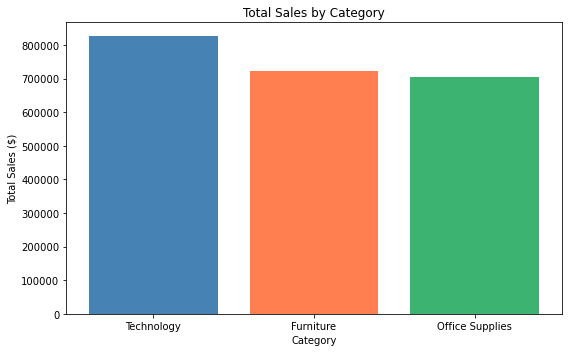

In [10]:
import matplotlib.pyplot as plt

# Sales by Category chart
category_sales = df2.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values, color=["steelblue", "coral", "mediumseagreen"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

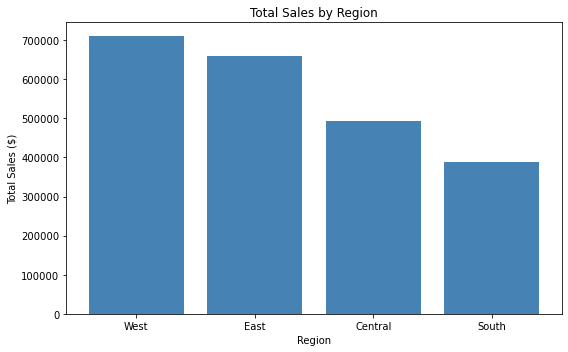

In [11]:
# Sales by Region chart
region_sales = df2.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values, color="steelblue")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

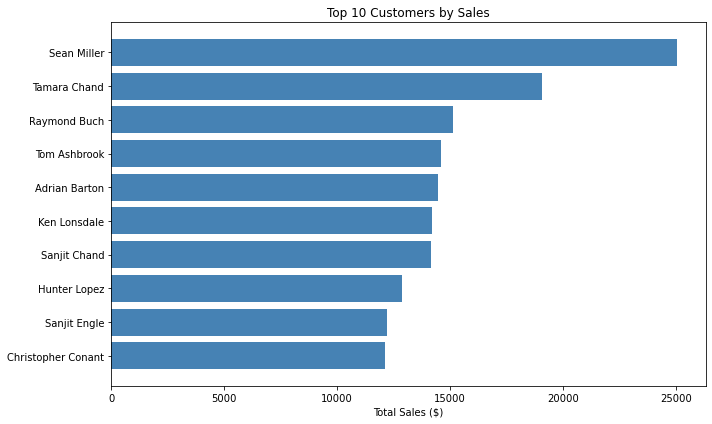

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [12]:
# Top 10 customers by sales
top_customers = df2.groupby("Customer Name")["Sales"].sum().nlargest(10)

plt.figure(figsize=(10, 6))
plt.barh(top_customers.index, top_customers.values, color="steelblue")
plt.xlabel("Total Sales ($)")
plt.title("Top 10 Customers by Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_customers.png", dpi=150)
plt.show()

print(top_customers)